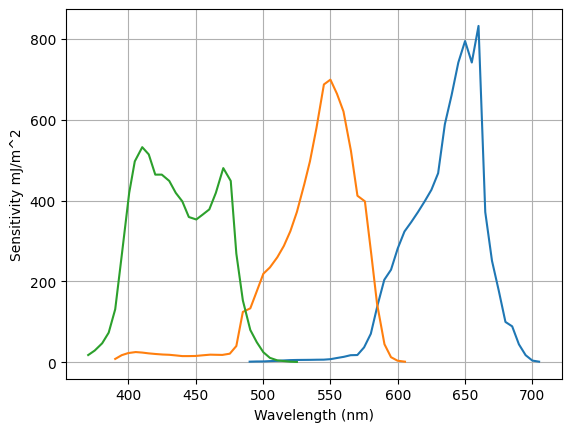

white ▉
44188.07122743963
             x         y
0   355.180723  0.983929
1   360.361446  0.986402
2   365.143652  0.990110
3   370.324374  0.988874
4   375.106580  0.983929
..         ...       ...
81  765.254866  0.997528
82  765.254866  0.997528
83  770.037071  0.997528
84  774.819277  0.998764
85  780.000000  0.998764

[86 rows x 2 columns]


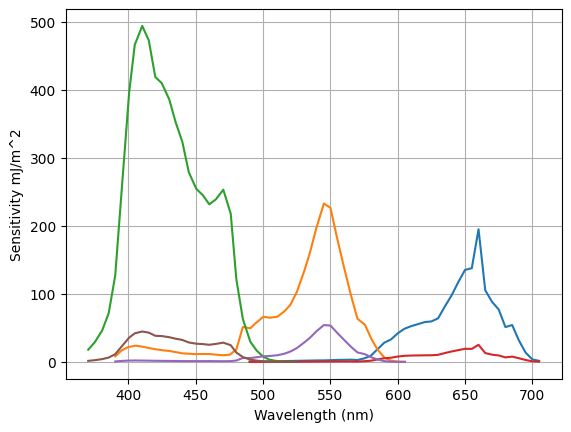

Leaf ▉
Leafx2 ▉
Leafx4 ▉
25 14 8
KB20+Leaf ▉
KB20+Leafx2 ▉
KB20+Leafx4 ▉
KB20+Leafx8 ▉
Exposure loss KB20 1.850619696681477 Ev


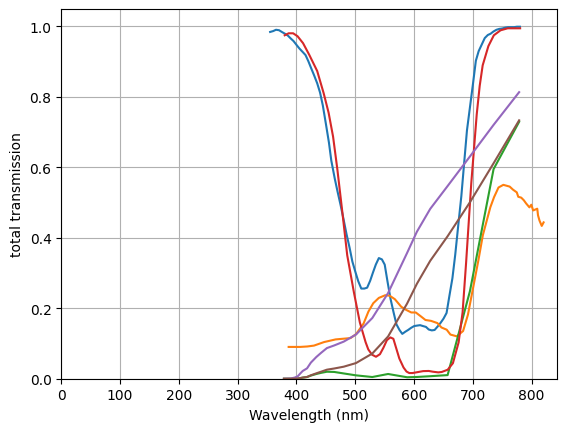

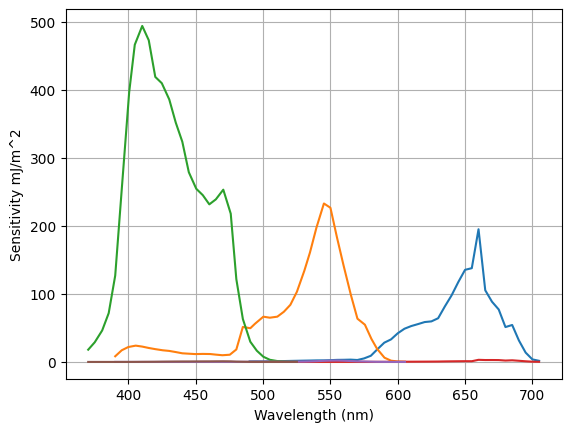

In [73]:
"""spectral analysis(colormaster)"""
"""By Matija Breljak"""
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from colorist import ColorRGB
x=[490, 495, 500, 505, 510, 515, 520 , 525, 530, 535, 540, 545, 550, 555, 560,565, 570, 575,580,585,590,595,600,605,610,615,620,625,630,635,640,645,650,655,660,665, 670, 675, 680,685, 690, 695, 700, 705]
y=[0.25,0.65,1.25,1.65,1.95,2,2.25,2.4,2.57,2.92,2.87,2.9,2.87,2.82,2.77,2.67,2.63,2.6,2.57,2.54,2.51,2.45,2.36,2.31,2.15,1.85,1.57,1.26,1.25,1.14,1.04,0.9,0.83,0.82,0.8,0.79,0.778,0.75,0.68,0.57,0.5,0.37,0.35,0.25]
y.reverse()
yt = [10**i  for i in y]
Magenta = pd.read_csv("/content/sample_data/Kodak-Portra-800-MagentaForming-data.csv")
Yellow = pd.read_csv("/content/sample_data/Kodak-Portra-800-YellowForming-data.csv")
M=np.array(Magenta.iloc[:, 0]), [10**i  for i in np.array(Magenta.iloc[:, 1])]
Y=np.array(Yellow.iloc[:, 0]), [10**i  for i in np.array(Yellow.iloc[:, 1])]
plt.xlabel("Wavelength (nm)")
plt.ylabel("Sensitivity mJ/m^2")
plt.grid()
plt.plot(x, yt)
plt.plot(M[0],M[1])
plt.plot(Y[0],Y[1])
plt.show()
inp=(x,yt)
def WhiteDv(r,g,b):
  return max(r,g,b)

dusty_pink = ColorRGB(194, 145, 164)
def colorvalue(x,y):
  z=0
  for i in range(len(x)-1):
    z=z+(x[i+1]-x[i])*y[i]
  return z
def color(r,g,b):
  a=max(r,g,b)
  r=r/a
  g=g/a
  b=b/a
  return (int(255*r),int(255*g),int(255*b))
wdiv=WhiteDv(colorvalue(inp[0],inp[1]),colorvalue(M[0],M[1]),colorvalue(Y[0],Y[1]))
a=ColorRGB(color(colorvalue(inp[0],inp[1]),colorvalue(M[0],M[1]),colorvalue(Y[0],Y[1]))[0],color(colorvalue(inp[0],inp[1]),colorvalue(M[0],M[1]),colorvalue(Y[0],Y[1]))[1],color(colorvalue(inp[0],inp[1]),colorvalue(M[0],M[1]),colorvalue(Y[0],Y[1]))[2])
print(f"white {a}▉{ColorRGB.OFF}")
print(wdiv)


Filter = pd.read_csv("/content/sample_data/fn-data.csv")
LeafSp = pd.read_csv("/content/sample_data/LEAF-REFLECTANCE2-data.csv")
KB12 = pd.read_csv("/content/sample_data/KB-12-data.csv")
KR12 = pd.read_csv("/content/sample_data/KR-12-data.csv")

print(Filter)
def FilterMult(Filter, x):
    x_coords, y_coords = np.array(x[0]), np.array(x[1])
    filter_x, filter_y = np.array(Filter.iloc[:, 0]), np.array(Filter.iloc[:, 1])

    interpolated_filter = np.interp(x_coords, filter_x, filter_y)

    return [x_coords.tolist(), (y_coords * interpolated_filter).tolist()]

def FilterMultFF(F1, F2):
    x_coords, y_coords = np.array(F1.iloc[:, 0]), np.array(F1.iloc[:, 1])
    filter_x, filter_y = np.array(F2.iloc[:, 0]), np.array(F2.iloc[:, 1])

    interpolated_filter = np.interp(x_coords, filter_x, filter_y)
    return pd.DataFrame({
    "x": x_coords,
    "y": y_coords * interpolated_filter
})

def plot(Filter,C,M,Y):
  plt.plot(*FilterMult(Filter,C))
  plt.plot(*FilterMult(Filter,M))
  plt.plot(*FilterMult(Filter,Y))

plt.xlabel("Wavelength (nm)")
plt.ylabel("Sensitivity mJ/m^2")
plt.grid()
plot(Filter,inp,M,Y)
plot(LeafSp,FilterMult(Filter,inp),FilterMult(Filter,M),FilterMult(Filter,Y))
plt.show()
R=FilterMult(LeafSp,inp)
G=FilterMult(LeafSp,M)
B=FilterMult(LeafSp,Y)
LPFR=int(255*colorvalue(R[0],R[1])/wdiv)
LPFG=int(255*colorvalue(G[0],G[1])/wdiv)
LPFB=int(255*colorvalue(B[0],B[1])/wdiv)

LeafPostFilter=ColorRGB(LPFR,LPFG,LPFB)
LeafPostFilterx2=ColorRGB(2*LPFR,2*LPFG,2*LPFB)
LeafPostFilterx4=ColorRGB(4*LPFR,4*LPFG,4*LPFB)

print(f"Leaf {LeafPostFilter}▉{ColorRGB.OFF}")
print(f"Leafx2 {LeafPostFilterx2}▉{ColorRGB.OFF}")
print(f"Leafx4 {LeafPostFilterx4}▉{ColorRGB.OFF}")

KB24=FilterMultFF(KB12,KB12)
KR24=FilterMultFF(KR12,KR12)
KR36=FilterMultFF(KR24,KR12)
KBKR2436=FilterMultFF(KR36,KB24)

R=FilterMult(LeafSp,FilterMult(KBKR2436,inp))
G=FilterMult(LeafSp,FilterMult(KBKR2436,M))
B=FilterMult(LeafSp,FilterMult(KBKR2436,Y))
LPFR=int(32*255*colorvalue(R[0],R[1])/wdiv)
LPFG=int(32*255*colorvalue(G[0],G[1])/wdiv)
LPFB=int(32*255*colorvalue(B[0],B[1])/wdiv)
print(LPFR,LPFG,LPFB)
LeafPostFilter=ColorRGB(LPFR,LPFG,LPFB)
LeafPostFilterx2=ColorRGB(2*LPFR,2*LPFG,2*LPFB)
LeafPostFilterx4=ColorRGB(4*LPFR,4*LPFG,4*LPFB)
LeafPostFilterx8=ColorRGB(8*LPFR,8*LPFG,8*LPFB)
#LeafPostFilterx16=ColorRGB(16*LPFR,16*LPFG,16*LPFB)
#LeafPostFilterx32=ColorRGB(32*LPFR,32*LPFG,32*LPFB)
#LeafPostFilterx64=ColorRGB(64*LPFR,64*LPFG,64*LPFB)
#LeafPostFilterx128=ColorRGB(512*LPFR,512*LPFG,512*LPFB)



print(f"KB20+Leaf {LeafPostFilter}▉{ColorRGB.OFF}")
print(f"KB20+Leafx2 {LeafPostFilterx2}▉{ColorRGB.OFF}")
print(f"KB20+Leafx4 {LeafPostFilterx4}▉{ColorRGB.OFF}")
print(f"KB20+Leafx8 {LeafPostFilterx8}▉{ColorRGB.OFF}")
#print(f"KB20+Leafx4 {LeafPostFilterx16}▉{ColorRGB.OFF}")
#print(f"KB20+Leafx8 {LeafPostFilterx32}▉{ColorRGB.OFF}")
#print(f"KB20+Leafx4 {LeafPostFilterx64}▉{ColorRGB.OFF}")
#print(f"KB20+Leafx8 {LeafPostFilterx128}▉{ColorRGB.OFF}")

R=FilterMult(KBKR2436,inp)
G=FilterMult(KBKR2436,M)
B=FilterMult(KBKR2436,Y)
exposureloss=np.log10((colorvalue(inp[0],inp[1])+colorvalue(M[0],M[1])+colorvalue(Y[0],Y[1]))/(colorvalue(R[0],R[1])+colorvalue(G[0],G[1])+colorvalue(B[0],B[1])))
print("Exposure loss KB20",exposureloss,"Ev")
plt.xlabel("Wavelength (nm)")
plt.ylabel("total transmission")
plt.grid()
plt.plot(np.array(Filter.iloc[:, 0]), np.array(Filter.iloc[:, 1]))
plt.plot(np.array(LeafSp.iloc[:, 0]), np.array(LeafSp.iloc[:, 1]))
plt.plot(np.array(KBKR2436.iloc[:, 0]), np.array(KBKR2436.iloc[:, 1]))
plt.plot(np.array(KB24.iloc[:, 0]), np.array(KB24.iloc[:, 1]))
plt.plot(np.array(KR24.iloc[:, 0]), np.array(KR24.iloc[:, 1]))
plt.plot(np.array(KR36.iloc[:, 0]), np.array(KR36.iloc[:, 1]))

plt.xlim(0, )
plt.ylim(0, )
plt.show()

plt.xlabel("Wavelength (nm)")
plt.ylabel("Sensitivity mJ/m^2")
plt.grid()
plot(Filter,inp,M,Y)
plot(LeafSp,FilterMult(KBKR2436,inp),FilterMult(KBKR2436,M),FilterMult(KBKR2436,Y))
plt.show()
